In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


plt.style.use("fivethirtyeight")

Для генерации используется библиотечная функция:
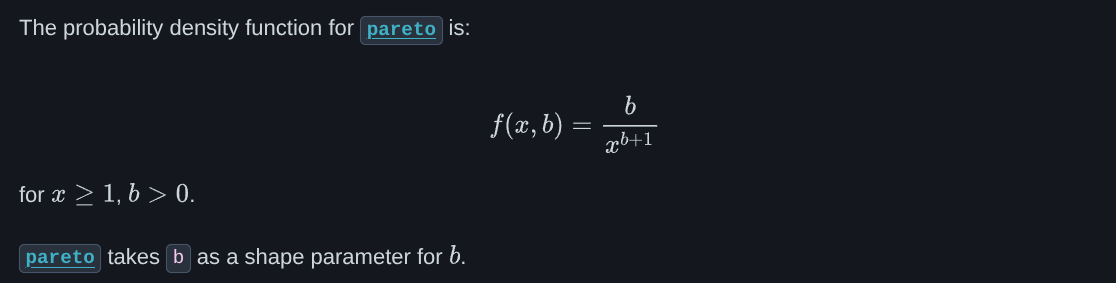

In [41]:
# Задаем выборку

n = 100

θ = 3
sample = stats.pareto.rvs(b=(θ - 1), size=n)

sample

array([1.06452743, 1.17937172, 1.32425484, 1.01453972, 1.29366997,
       1.14073223, 1.34527258, 4.05933035, 3.48946521, 1.21875792,
       1.14849257, 1.66603935, 9.582361  , 1.38053984, 2.05311634,
       3.80092749, 2.00421079, 1.07452455, 1.40103315, 1.37972516,
       1.54217049, 1.00478254, 1.41148355, 1.03914   , 1.94206768,
       1.20090479, 1.09511343, 1.60718607, 1.21527477, 3.81187222,
       1.23450461, 1.37354708, 1.00420346, 1.10199512, 1.27057346,
       1.09561457, 2.01281143, 2.68339368, 1.04921616, 1.44312199,
       1.28158276, 1.15581418, 3.37473801, 1.29369617, 8.52111492,
       1.52621528, 1.11828822, 2.21404343, 1.02332381, 1.11058774,
       2.661381  , 6.48534426, 1.41306866, 1.39355594, 1.81652368,
       1.01529284, 1.2089696 , 1.40167806, 2.22135006, 7.26441795,
       1.69273994, 1.77331326, 1.19757932, 1.32371693, 1.51269871,
       1.15466497, 1.24994601, 1.82622218, 2.24415342, 1.19004245,
       1.57018401, 1.60634437, 1.75837081, 1.0242754 , 1.74215

# Вычислим доверительные интервалы

In [53]:
β = 0.95
θ_est = 1 + n / np.sum(np.log(sample))
θ_est

np.float64(3.2198003855391057)

## Асимптотический для медианы

In [ ]:
def g(θ):
    return np.pow(2, 1/(θ-1))


t1 = stats.norm.ppf((1 - β) / 2)
t2 = stats.norm.ppf((1 + β) / 2)

# здесь была обнаружена и исправлена потеря минуса в pdf
boundaries_m = [g(θ_est) - t2 * g(θ_est) * np.log(2) / (np.sqrt(n) * (θ_est - 1)),
                g(θ_est) - t1 * g(θ_est) * np.log(2) / (np.sqrt(n) * (θ_est - 1))]
print(f"Доверительный интервал: [{boundaries_m[0]:.4f}, {boundaries_m[1]:.4f}]")
print(f"Длина: {(boundaries_m[1] - boundaries_m[0]):.4f}")

Доверительный интервал: [1.2829, 1.4501]
Длина: 0.1673


## Асимптотический для θ

In [68]:
def g(θ):
    return np.pow(2, 1/(θ+1))

t1 = stats.norm.ppf((1 - β) / 2)
t2 = stats.norm.ppf((1 + β) / 2)

boundaries_a = [θ_est - t2 * (θ_est - 1) / np.sqrt(n),
                θ_est - t1 * (θ_est - 1) / np.sqrt(n)]
print(f"Доверительный интервал: [{boundaries_a[0]:.4f}, {boundaries_a[1]:.4f}]")
print(f"Длина: {(boundaries_a[1] - boundaries_a[0]):.4f}")

Доверительный интервал: [2.7847, 3.6549]
Длина: 0.8701


## Бутстраповский

### Непараметрический

In [69]:
N = 1000

h = θ_est
delta_series = np.zeros(shape=N) # для получения вариационного ряда Δ(i)
for i in range(N):
    bootstrap_sample = np.random.choice(sample, size=n)
    delta_series[i] = (1 + n / np.sum(np.log(bootstrap_sample))) - h
delta_series = np.sort(delta_series)

κ1 = int(np.round((1-β) / 2 * N))
κ2 = int(np.round((1+β) / 2 * N))

Δκ1 = delta_series[κ1]
Δκ2 = delta_series[κ2]

boundaries_bnp = [h - Δκ2, h - Δκ1]
print(f"Доверительный интервал: [{boundaries_bnp[0]:.4f}, {boundaries_bnp[1]:.4f}]")
print(f"Длина: {(boundaries_bnp[1] - boundaries_bnp[0]):.4f}")

Доверительный интервал: [2.6964, 3.5880]
Длина: 0.8916


### Параметрический

In [70]:
N = 50000

h = θ_est
delta_series = np.zeros(shape=N) # для получения вариационного ряда Δ(i)
for i in range(N):
    bootstrap_sample = stats.pareto.rvs(
        b=(θ_est - 1),
        size=n
    )
    delta_series[i] = (1 + n / np.sum(np.log(bootstrap_sample))) - h
delta_series = np.sort(delta_series)

κ1 = int(np.round((1-β) / 2 * N))
κ2 = int(np.round((1+β) / 2 * N))

Δκ1 = delta_series[κ1]
Δκ2 = delta_series[κ2]

boundaries_bp = [h - Δκ2, h - Δκ1]
print(f"Доверительный интервал: [{boundaries_bp[0]:.4f}, {boundaries_bp[1]:.4f}]")
print(f"Длина: {(boundaries_bp[1] - boundaries_bp[0]):.4f}")

Доверительный интервал: [2.7108, 3.5966]
Длина: 0.8858


# Сравнение доверительных интервалов

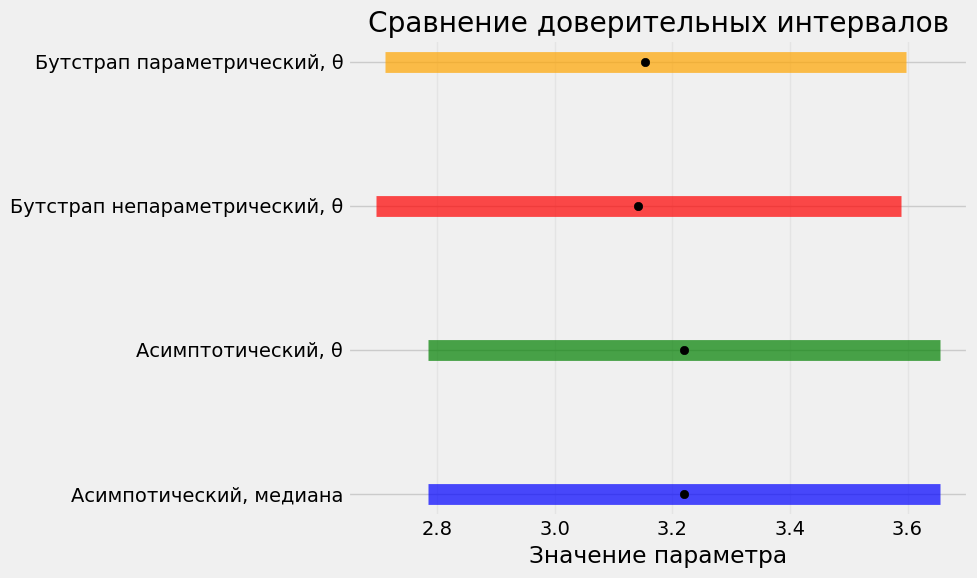

In [80]:
methods = ['Асимпотический, медиана',
           'Асимптотический, θ', 
           'Бутстрап непараметрический, θ',
           'Бутстрап параметрический, θ'
           ]
lower_bounds = [boundaries_m[0], boundaries_a[0], boundaries_bnp[0], boundaries_bp[0]]
upper_bounds = [boundaries_m[1], boundaries_a[1], boundaries_bnp[1], boundaries_bp[1]]


fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(methods))

ax.hlines(y_pos, lower_bounds, upper_bounds,
           color=['blue', 'green', 'red', 'orange'],
           linewidth=15, alpha=0.7)


centers = [(low + high) / 2 for low, high in zip(lower_bounds, upper_bounds)]
ax.scatter(centers, y_pos, color='black', zorder=5)


ax.set_yticks(y_pos)
ax.set_yticklabels(methods)
ax.set_xlabel('Значение параметра')
ax.set_title('Сравнение доверительных интервалов')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
